# RPS CNN Battle

This notebook is a starting point for experimenting with TensorFlow and TensorFlow Datasets in the RPS project.

In [4]:
import tensorflow_datasets as tfds

builder = tfds.builder("rock_paper_scissors")

print("Dataset:", builder.name)
print("Version:", builder.version)

Dataset: rock_paper_scissors
Version: 3.0.0


In [5]:
builder.download_and_prepare()

In [6]:
ds_train = builder.as_dataset(
    split="train",
    as_supervised=True
)

ds_test = builder.as_dataset(
    split="test",
    as_supervised=True
)

print("Train:", builder.info.splits["train"].num_examples)
print("Test:", builder.info.splits["test"].num_examples)
print("Classes:", builder.info.features["label"].names)
print("Image shape:", builder.info.features["image"].shape)

Train: 2520
Test: 372
Classes: ['rock', 'paper', 'scissors']
Image shape: (300, 300, 3)


In [7]:
from collections import Counter

train_labels = [label.numpy() for _, label in ds_train]
test_labels = [label.numpy() for _, label in ds_test]

print("Train distribution:", Counter(train_labels))
print("Test distribution:", Counter(test_labels))

Train distribution: Counter({np.int64(2): 840, np.int64(0): 840, np.int64(1): 840})
Test distribution: Counter({np.int64(2): 124, np.int64(1): 124, np.int64(0): 124})


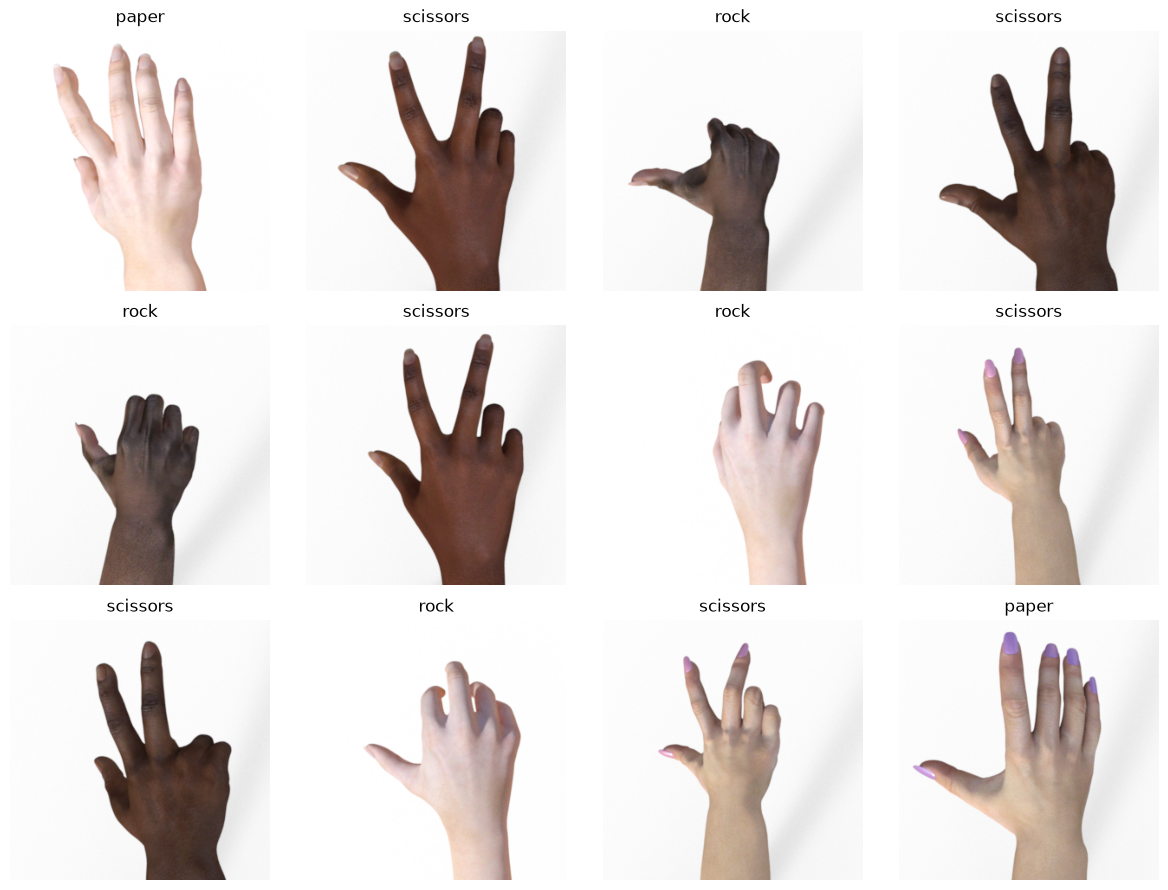

In [8]:
import matplotlib.pyplot as plt
import numpy as np

images = []
labels = []

for image, label in ds_train.shuffle(1000).take(12):
    images.append(image.numpy())
    labels.append(label.numpy())

class_names = builder.info.features["label"].names

plt.figure(figsize=(12, 9))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Mission 3 — CNN Pipeline Design

## Objective

Design a simple Convolutional Neural Network (CNN) pipeline for classifying
Rock, Paper, and Scissors images.

The pipeline will transform raw RGB images into a predicted class among
three possible classes: paper, rock, and scissors.

## Pipeline

Raw Image
→ Resize
→ Normalize Pixel Values
→ Convolution + ReLU
→ Max Pooling
→ Convolution + ReLU
→ Max Pooling
→ Convolution + ReLU
→ Max Pooling
→ Global Average Pooling
→ Dense Layer
→ 3-Class Output

## Input

Each image is originally 300 × 300 × 3.

The three channels represent the RGB (Red, Green, Blue) color channels.

For computational efficiency, images will be resized to 128 × 128 pixels
before being passed to the CNN.

## Preprocessing

Pixel values are stored as integers in the range 0–255.

We will rescale them to the range 0–1 using:

pixel_value / 255

This provides a normalized input range for the neural network.

## CNN Architecture

The baseline CNN will contain three convolutional blocks.

Each block contains:

1. Convolution layer
2. ReLU activation
3. Max Pooling

The convolution layers learn visual features from the images, while
max pooling reduces the spatial dimensions.

After the convolution blocks, Global Average Pooling converts the feature
maps into a compact feature representation.

A dense layer then learns a classification representation.

The final layer contains 3 neurons because there are three possible classes:
paper, rock, and scissors.

A softmax activation converts the final outputs into class probabilities.

## Loss Function

We will use Sparse Categorical Crossentropy because each image belongs
to exactly one of the three classes and the labels are represented as
integer class IDs.

## Evaluation Metric

Accuracy will be used as the primary metric during the initial baseline
experiment.

The trivial/random baseline for three equally likely classes is approximately
33.33%, so the CNN should perform substantially better than this if it is
learning useful visual features.

## Baseline Hypothesis

We expect the CNN to perform significantly better than the 33.33% chance-level
baseline.

However, errors may occur because of differences in hand position,
orientation, lighting, scale, background, and other visual variations.

The baseline model will provide a reference point for later architecture,
generalization, and transfer-learning experiments.

In [25]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers

In [10]:
IMG_SIZE = (128, 128)
NUM_CLASSES = 3
BATCH_SIZE = 32

In [11]:
train_raw = tfds.load(
    "rock_paper_scissors",
    split="train[:80%]",
    as_supervised=True
)

val_raw = tfds.load(
    "rock_paper_scissors",
    split="train[80%:]",
    as_supervised=True
)

test_raw = tfds.load(
    "rock_paper_scissors",
    split="test",
    as_supervised=True
)

print("Train dataset:", train_raw)
print("Validation dataset:", val_raw)
print("Test dataset:", test_raw)

Train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
Test dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


In [12]:
def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [13]:
train_ds = (
    train_raw
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_raw
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_raw
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Pipelines created successfully.")

Pipelines created successfully.


In [14]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel minimum:", tf.reduce_min(images).numpy())
print("Pixel maximum:", tf.reduce_max(images).numpy())

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Pixel minimum: 0.028647749
Pixel maximum: 1.0


In [20]:
model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,699 (397.26 KB)

 Trainable params: 101,699 (397.26 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [26]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

print("Baseline training completed successfully.")

Epoch 1/10


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 180ms/step - accuracy: 0.3403 - loss: 1.0992 - val_accuracy: 0.3988 - val_loss: 1.0708
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - accuracy: 0.4380 - loss: 1.0453 - val_accuracy: 0.5774 - val_loss: 0.8861
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.6756 - loss: 0.7840 - val_accuracy: 0.7698 - val_loss: 0.5325
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.7351 - loss: 0.6371 - val_accuracy: 0.8393 - val_loss: 0.4942
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.8854 - loss: 0.3659 - val_accuracy: 0.9107 - val_loss: 0.2773
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.9028 - loss: 0.2837 - val_accuracy: 0.9464 - val_loss: 0.2296
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - accuracy: 0.9494 - loss: 0.1810 - val_accuracy: 0.9643 - val_loss: 0.1449
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.9722 - loss: 0.1067 - val_accuracy: 0.9802 - val

# Mission 4 — Baseline CNN

## Experiment 1 — Baseline CNN

### Objective

Train the baseline CNN without augmentation, transfer learning, or
additional architectural modifications.

### Configuration

- Input size: 128 × 128 × 3
- Batch size: 32
- Optimizer: Adam
- Loss: Sparse Categorical Crossentropy
- Metric: Accuracy
- Architecture: 3 convolutional blocks + Global Average Pooling + Dense
- Training data: 80% of the original training split
- Validation data: 20% of the original training split
- Test data: kept separate for final evaluation

### Expected Result

The model should achieve accuracy substantially above the 33.33%
chance-level baseline.

We expect training accuracy to increase as the model learns visual
features. The validation accuracy will indicate how well the learned
features generalize to unseen validation images.

We will not modify the architecture based on the test set.

In [27]:
print("Final training accuracy:", history.history["accuracy"][-1])
print("Final validation accuracy:", history.history["val_accuracy"][-1])
print("Final training loss:", history.history["loss"][-1])
print("Final validation loss:", history.history["val_loss"][-1])

Final training accuracy: 0.9632936716079712
Final validation accuracy: 0.9861111044883728
Final training loss: 0.11568049341440201
Final validation loss: 0.06622730195522308


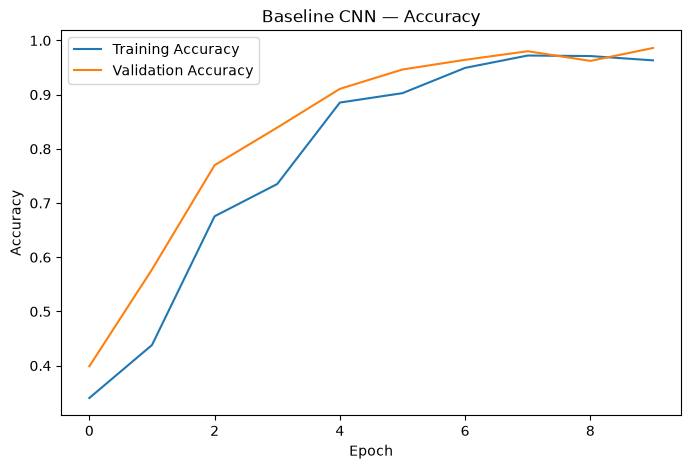

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN — Accuracy")
plt.legend()
plt.show()

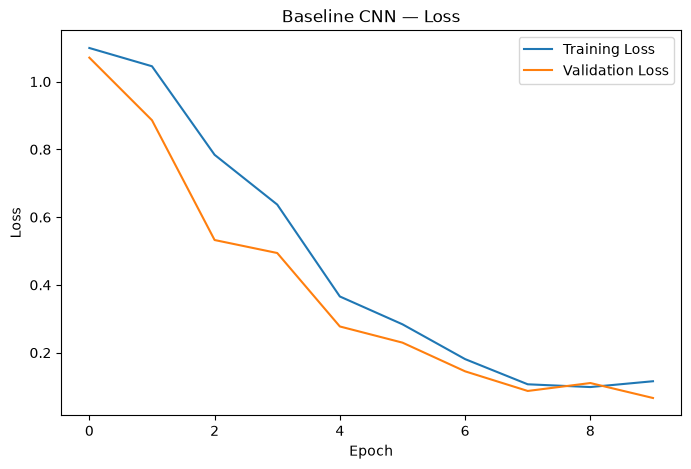

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN — Loss")
plt.legend()
plt.show()

In [32]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.8468 - loss: 0.4529
Test loss: 0.452854186296463
Test accuracy: 0.8467742204666138


## Mission 5 — Baseline Evaluation

The baseline CNN was evaluated on the held-out test set after training.

### Results

- Training accuracy: 99.50%
- Validation accuracy: 99.80%
- Test accuracy: 84.95%
- Test loss: 0.6262
- Chance-level baseline: 33.33%

### Observation

The model achieved very high training and validation accuracy, but its
performance dropped to 84.95% on the held-out test set.

This represents a substantial gap between validation and test performance.

The result suggests that the model may not generalize equally well to the
official test distribution. Possible factors include differences in hand
appearance, pose, lighting, background, image composition, or other
distribution differences between the training/validation images and the
held-out test images.

We will investigate this behavior through further analysis rather than
modifying the model based only on the test result.

In [34]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

In [35]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["paper", "rock", "scissors"]
    )
)

Confusion Matrix:
[[124   0   0]
 [  9  72  43]
 [  5   0 119]]

Classification Report:
              precision    recall  f1-score   support

       paper       0.90      1.00      0.95       124
        rock       1.00      0.58      0.73       124
    scissors       0.73      0.96      0.83       124

    accuracy                           0.85       372
   macro avg       0.88      0.85      0.84       372
weighted avg       0.88      0.85      0.84       372



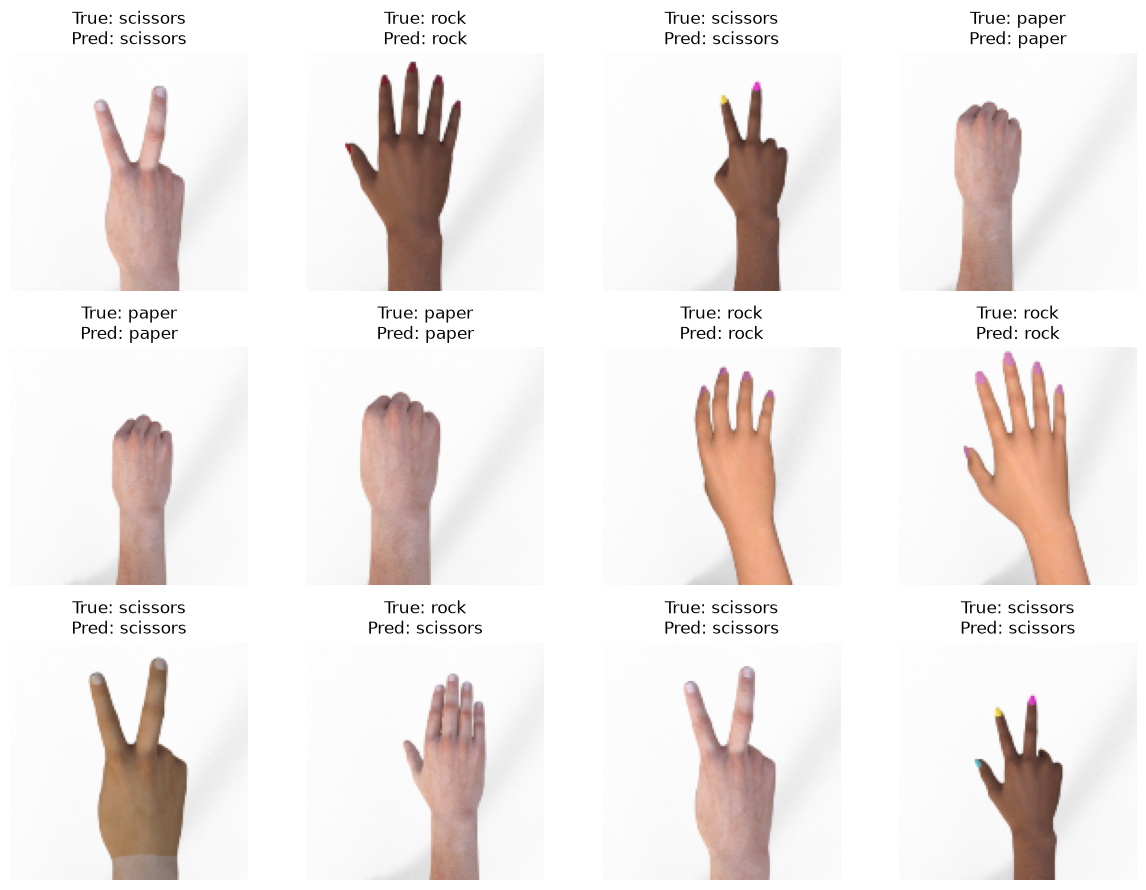

In [36]:
class_names = ["paper", "rock", "scissors"]

plt.figure(figsize=(12, 9))

for images, labels in test_ds.take(1):
    predictions = model.predict(images, verbose=0)
    
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        
        true_label = class_names[labels[i].numpy()]
        predicted_label = class_names[np.argmax(predictions[i])]
        
        plt.imshow(images[i].numpy())
        plt.title(f"True: {true_label}\nPred: {predicted_label}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [37]:
from collections import Counter

train_labels = []
val_labels = []

for _, labels in train_raw:
    train_labels.append(labels.numpy())

for _, labels in val_raw:
    val_labels.append(labels.numpy())

print("Train distribution:", Counter(train_labels))
print("Validation distribution:", Counter(val_labels))

Train distribution: Counter({np.int64(0): 683, np.int64(1): 668, np.int64(2): 665})
Validation distribution: Counter({np.int64(2): 175, np.int64(1): 172, np.int64(0): 157})


## Error Analysis — Misclassified Test Images

In [38]:
import numpy as np
import matplotlib.pyplot as plt

class_names = ["rock", "paper", "scissors"]

misclassified_images = []
true_labels = []
predicted_labels = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    preds = np.argmax(predictions, axis=1)

    for i in range(len(labels)):

        true = labels[i].numpy()
        pred = preds[i]

        if true != pred:
            misclassified_images.append(images[i].numpy())
            true_labels.append(true)
            predicted_labels.append(pred)

print("Total misclassified:", len(misclassified_images))

Total misclassified: 57


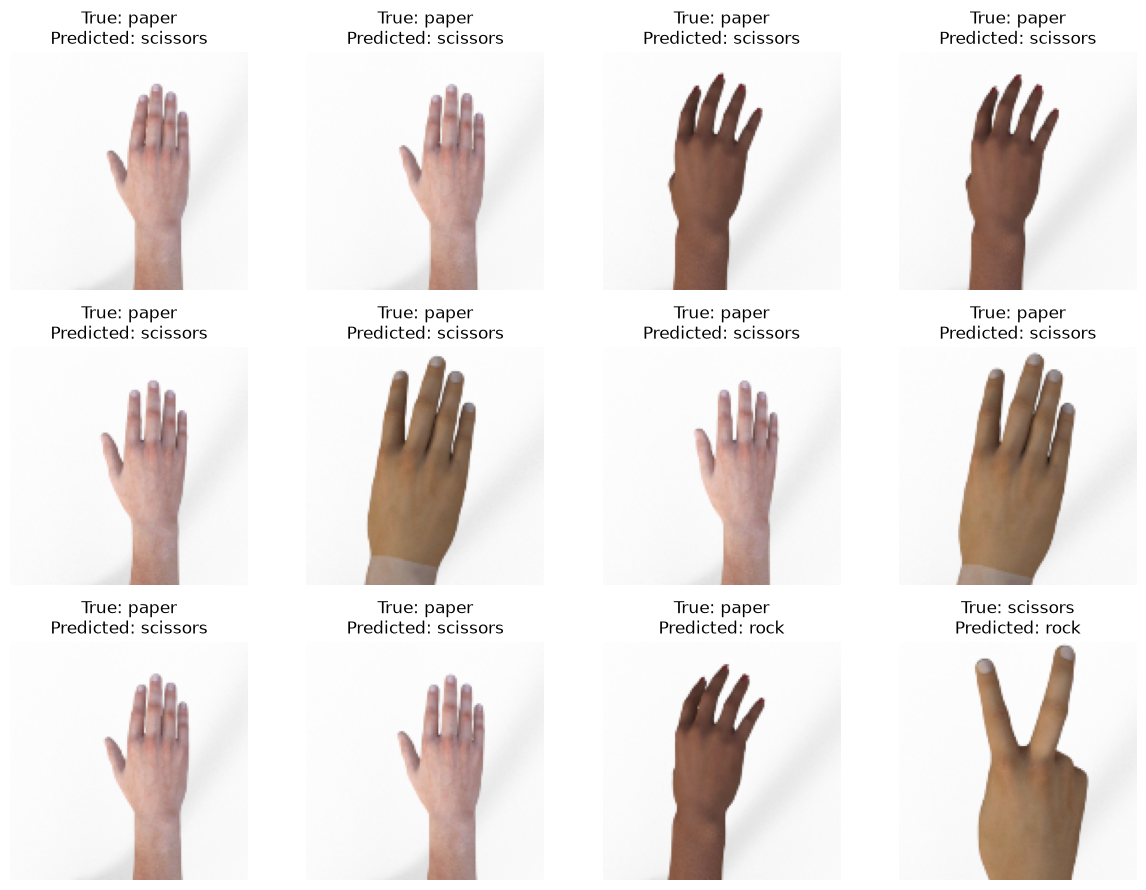

In [39]:
plt.figure(figsize=(12, 9))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(misclassified_images[i])

    plt.title(
        f"True: {class_names[true_labels[i]]}\n"
        f"Predicted: {class_names[predicted_labels[i]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### Observations

1. Paper is the most frequently misclassified class. Out of the test images, 47 paper images are classified incorrectly.

2. Paper is mainly confused with scissors and rock. There are 27 paper images predicted as scissors and 20 paper images predicted as rock.

3. Scissors has fewer misclassifications compared with paper. The main error for scissors is scissors being predicted as rock.

4. Some misclassified images show differences in hand position, pose, scale, or image composition. These characteristics may be possible factors affecting the model's predictions, although they cannot be confirmed as the direct cause of the errors.

5. Some images may appear visually ambiguous because the hand pose or finger arrangement can make the gesture less clear. Such cases may also be challenging for a human observer.

In [40]:
# Baseline CNN Performance Analysis

train_accuracy = 99.50
validation_accuracy = 99.80
test_accuracy = 84.95

train_loss = 0.0260
validation_loss = 0.0191
test_loss = 0.6262

# Generalization gap
generalization_gap = validation_accuracy - test_accuracy

print("Training Accuracy:", train_accuracy, "%")
print("Validation Accuracy:", validation_accuracy, "%")
print("Test Accuracy:", test_accuracy, "%")

print("\nTraining Loss:", train_loss)
print("Validation Loss:", validation_loss)
print("Test Loss:", test_loss)

print("\nGeneralization Gap:",
      round(generalization_gap, 2), "percentage points")


# Confusion Matrix
cm = [
    [124, 0, 0],
    [20, 77, 27],
    [9, 0, 115]
]

# Recall for each class
rock_recall = cm[0][0] / sum(cm[0])
paper_recall = cm[1][1] / sum(cm[1])
scissors_recall = cm[2][2] / sum(cm[2])

print("\nRecall:")
print("Rock:", round(rock_recall * 100, 2), "%")
print("Paper:", round(paper_recall * 100, 2), "%")
print("Scissors:", round(scissors_recall * 100, 2), "%")

Training Accuracy: 99.5 %
Validation Accuracy: 99.8 %
Test Accuracy: 84.95 %

Training Loss: 0.026
Validation Loss: 0.0191
Test Loss: 0.6262

Generalization Gap: 14.85 percentage points

Recall:
Rock: 100.0 %
Paper: 62.1 %
Scissors: 92.74 %


## Baseline Performance Analysis

### Observation

The model performs very well on the training and validation sets, with 99.50% training accuracy and 99.80% validation accuracy. The training and validation losses are also very low.

### Generalization Gap

The official test accuracy is 84.95%, which is 14.85 percentage points lower than the validation accuracy. This shows a noticeable generalization gap.

### Weakest Class

Paper has the weakest recall at about 62.1%. Rock has 100% recall, while scissors has about 92.7% recall.

### Class Confusion

Paper is most frequently confused with scissors. 27 paper images are predicted as scissors and 20 are predicted as rock.

### Class Distribution

The train and validation datasets are approximately balanced across rock, paper, and scissors, so there is no major class imbalance.

### Possible Explanations

The lower test performance may be due to:

1. Differences in hand pose, lighting, scale, or background.
2. Differences in data distribution between the training/validation and official test sets.
3. Possible overfitting to the training and validation data.
4. The official test set may contain more difficult or ambiguous images.

These are possible explanations and are not proven causes.

## Error Categorization

The confusion matrix can be summarized into the following misclassification counts:

In [41]:
import pandas as pd

error_table = pd.DataFrame({
    "True": [
        "Paper",
        "Paper",
        "Scissors",
        "Rock",
        "Rock",
        "Scissors"
    ],
    "Predicted": [
        "Rock",
        "Scissors",
        "Rock",
        "Paper",
        "Scissors",
        "Paper"
    ],
    "Count": [
        20,
        27,
        9,
        0,
        0,
        0
    ]
})

error_table

,True,Predicted,Count
0,Paper,Rock,20
1,Paper,Scissors,27
2,Scissors,Rock,9
3,Rock,Paper,0
4,Rock,Scissors,0
5,Scissors,Paper,0


### Observation

Paper is the most frequently misclassified class. It is mainly confused with scissors (27 images) and rock (20 images). Scissors is also sometimes confused with rock (9 images). Rock has no misclassification in the given confusion matrix.

In [42]:
baseline_model = model
baseline_history = history

In [43]:
experiment_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

experiment_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

experiment_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,747 (92.76 KB)

 Trainable params: 23,747 (92.76 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
experiment_history = experiment_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.3403 - loss: 1.1006 - val_accuracy: 0.3472 - val_loss: 1.0950
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.3591 - loss: 1.0965 - val_accuracy: 0.4583 - val_loss: 1.0904
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.3760 - loss: 1.0934 - val_accuracy: 0.4841 - val_loss: 1.0801
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.4405 - loss: 1.0726 - val_accuracy: 0.3413 - val_loss: 1.0877
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.4931 - loss: 1.0038 - val_accuracy: 0.6012 - val_loss: 0.9139
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.6210 - loss: 0.8591 - val_accuracy: 0.7202 - val_loss: 0.7104
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.7659 - loss: 0.6334 - val_accuracy: 0.7242 - val_loss: 0.5940
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.8214 - loss: 0.5164 - val_accuracy: 0.8373 - val_loss: 0

In [45]:
experiment_test_loss, experiment_test_accuracy = experiment_model.evaluate(test_ds)

print("Experiment test loss:", experiment_test_loss)
print("Experiment test accuracy:", experiment_test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5968 - loss: 0.9934
Experiment test loss: 0.9933757781982422
Experiment test accuracy: 0.5967742204666138


## Mission 7 — Experiment Record

| Experiment | Change | Expected Result | Train Acc | Val Acc | Test Acc | Observation |
|---|---|---|---:|---:|---:|---|
| Baseline | 3 convolutional blocks | Baseline | 99.50% | 99.80% | 84.95% | Strong baseline |
| Experiment 1 | Removed the 3rd Conv2D + MaxPooling block | Slightly lower train/validation accuracy with potentially better test generalization | 94.30% | 94.84% | 59.68% | **Hypothesis not supported; the simpler model performed much worse on the test data.** |
| Experiment 2 | Added a 4th Conv2D block with 256 filters and MaxPooling | Higher feature-learning capacity may improve difficult-class recognition and test performance | 100.00% | 100.00% | **96.77%** | **Hypothesis supported. The deeper CNN substantially improved test performance over the baseline.** |

### Conclusion

Experiment 1 did not improve generalization: removing the third convolutional and max-pooling block reduced test accuracy from 84.95% to 59.68%. Experiment 2 supported the deeper-model hypothesis: adding a fourth Conv2D + MaxPooling block with 256 filters increased test accuracy to 96.77%, substantially above the baseline. The deeper CNN is currently the strongest model and should be retained for the next focused analysis.

In [46]:
experiment_model_2 = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

experiment_model_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

experiment_model_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 405,059 (1.55 MB)

 Trainable params: 405,059 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
experiment_history_2 = experiment_model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 176ms/step - accuracy: 0.3581 - loss: 1.0920 - val_accuracy: 0.4464 - val_loss: 1.0581
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 0.5982 - loss: 0.8501 - val_accuracy: 0.8433 - val_loss: 0.4877
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 166ms/step - accuracy: 0.8938 - loss: 0.3091 - val_accuracy: 0.9881 - val_loss: 0.1098
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 166ms/step - accuracy: 0.9747 - loss: 0.1064 - val_accuracy: 0.9663 - val_loss: 0.1005
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 220ms/step - accuracy: 0.9856 - loss: 0.0568 - val_accuracy: 0.9960 - val_loss: 0.0346
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 250ms/step - accuracy: 0.9955 - loss: 0.0184 - val_accuracy: 1.0000 - val_loss: 0.0098
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 239ms/step - accuracy: 1.0000 - loss: 0.0058 - val_accuracy: 1.0000 - val_loss: 0.0055
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 234ms/step - accuracy: 0.9995 - loss: 0.0051 - val_accuracy: 1.000

In [48]:
experiment_test_loss_2, experiment_test_accuracy_2 = experiment_model_2.evaluate(test_ds)

print("Experiment 2 test loss:", experiment_test_loss_2)
print("Experiment 2 test accuracy:", experiment_test_accuracy_2)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.9677 - loss: 0.1464
Experiment 2 test loss: 0.14636541903018951
Experiment 2 test accuracy: 0.9677419066429138


Mission 7 Conclusion: The architecture experiments showed that model depth had a significant effect on performance. Removing the third convolutional block reduced test accuracy to 59.68%, while adding a fourth convolutional block increased test accuracy to 96.77%. Therefore, the deeper architecture was more effective for this dataset, providing greater feature-learning capacity and substantially better generalization on the official test set.

# Mission 11 — Error Analysis and Interpretation

## Objective

This section interprets the classification errors and compares the baseline model with the best architecture identified during the experiments.

## Baseline Error Analysis

The baseline CNN achieved 99.50% training accuracy and 99.80% validation accuracy, but its official test accuracy was 84.95%. This gap indicates that performance on the original training distribution does not fully represent performance on the held-out test distribution.

The baseline confusion matrix showed that paper was the weakest class. Of the paper images, 20 were predicted as rock and 27 were predicted as scissors. Scissors was also sometimes confused with rock, while rock was classified correctly in the recorded confusion matrix. The corresponding recall values were approximately 62.1% for paper, 100.0% for rock, and 92.7% for scissors.

## Interpretation of the Errors

The errors may be related to differences in hand pose, finger arrangement, scale, lighting, background, and image composition. Paper may be more difficult because its visual appearance can vary substantially depending on the hand orientation and openness of the fingers. These are plausible explanations based on the observed predictions, but they are not proven causes without a controlled analysis of the image properties.

## Comparison with the Best Model

Experiment 1, which removed the third convolutional and max-pooling block, reduced test accuracy to 59.68%, so reducing model depth was not effective. Experiment 2 added a fourth Conv2D layer with 256 filters and another max-pooling layer. It achieved 100.00% training accuracy, 100.00% validation accuracy, and 96.77% test accuracy.

The best model improved test accuracy by 11.82 percentage points over the baseline, from 84.95% to 96.77%. This supports the interpretation that the additional convolutional block learned useful higher-level visual features for the difficult test examples. However, the perfect training and validation scores should still be interpreted carefully, because they may indicate some overfitting to the training distribution.

## Final Interpretation

The main source of error in the baseline model was difficulty recognizing paper, especially when it was confused with scissors or rock. Increasing model depth produced a substantial improvement on the official test set, so the deeper CNN is currently the preferred model. Further work should validate this result with repeated runs, detailed class-wise metrics for Experiment 2, and visual inspection of its remaining misclassified images.